# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../../')

In [2]:
import glob
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, cross_validate

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed

import numpy as np

In [14]:
SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


In [15]:
df_tr, dstrb_idx = dsp.load_and_process_session(SESSIONS[0], std=0.03)


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
['all_spikes', 'CP_spikes', 'MOp_spikes', 'VAL_spikes', 'SSp_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.89969909729187% of trials
  warnings.warn(


Resulting all_spikes ephys data shape is (NxT): (15, 48000)
Resulting CP_spikes ephys data shape is (NxT): (267, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (190, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (126, 48000)
Skipped 8 trials
Otsu immobility threshold: 6.6387
Dropped 70 of 497 rows (14.08%).


In [18]:
df_tr['disturb_left'] = df_tr['disturb_score'].apply(lambda x: x[[1, 4, 5]])
df_design = dsp.drop_trials_sem_crosses_zero(df_tr, field_sem='disturb_left')


  drop_trials_sem_crosses_zero: by SEM: 243  |  by value: 424  |  kept: 242/425 (56.9%)


In [19]:
# bottom third by left forelimb disturb score
disturb_left_mean = np.stack(df_design['disturb_left'].values).mean(axis=1)
threshold = np.percentile(disturb_left_mean, 100)
mask = disturb_left_mean < threshold

df_strong = df_design[mask].copy()
df_strong['_disturb_left_mean'] = disturb_left_mean[mask]
df_strong = df_strong.sort_values('_disturb_left_mean').reset_index(drop=True)

print(f"Threshold (33rd percentile): {threshold:.3f}")
print(f"Selected {len(df_strong)} / {len(df_design)} trials")
print(f"disturb_left range: {df_strong['_disturb_left_mean'].min():.3f} to {df_strong['_disturb_left_mean'].max():.3f}")


Threshold (33rd percentile): -0.007
Selected 241 / 242 trials
disturb_left range: -1.610 to -0.018


In [20]:
perturb_td = pyal.restrict_to_interval(
    df_strong,
    start_point_name="idx_sol_on",
    rel_start=-200,
    rel_end=300,
)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
perturb_td_shuff = dt.add_bhv(perturb_td_shuff, bhv_fields=['left_paw','left_elbow', 'left_wrist'])

/tmp/ipykernel_2218241/2720269645.py:1: UserWarning: Dropping 1 trials because of invalid time indexing. For more information, try warn_per_trial=True
  perturb_td = pyal.restrict_to_interval(


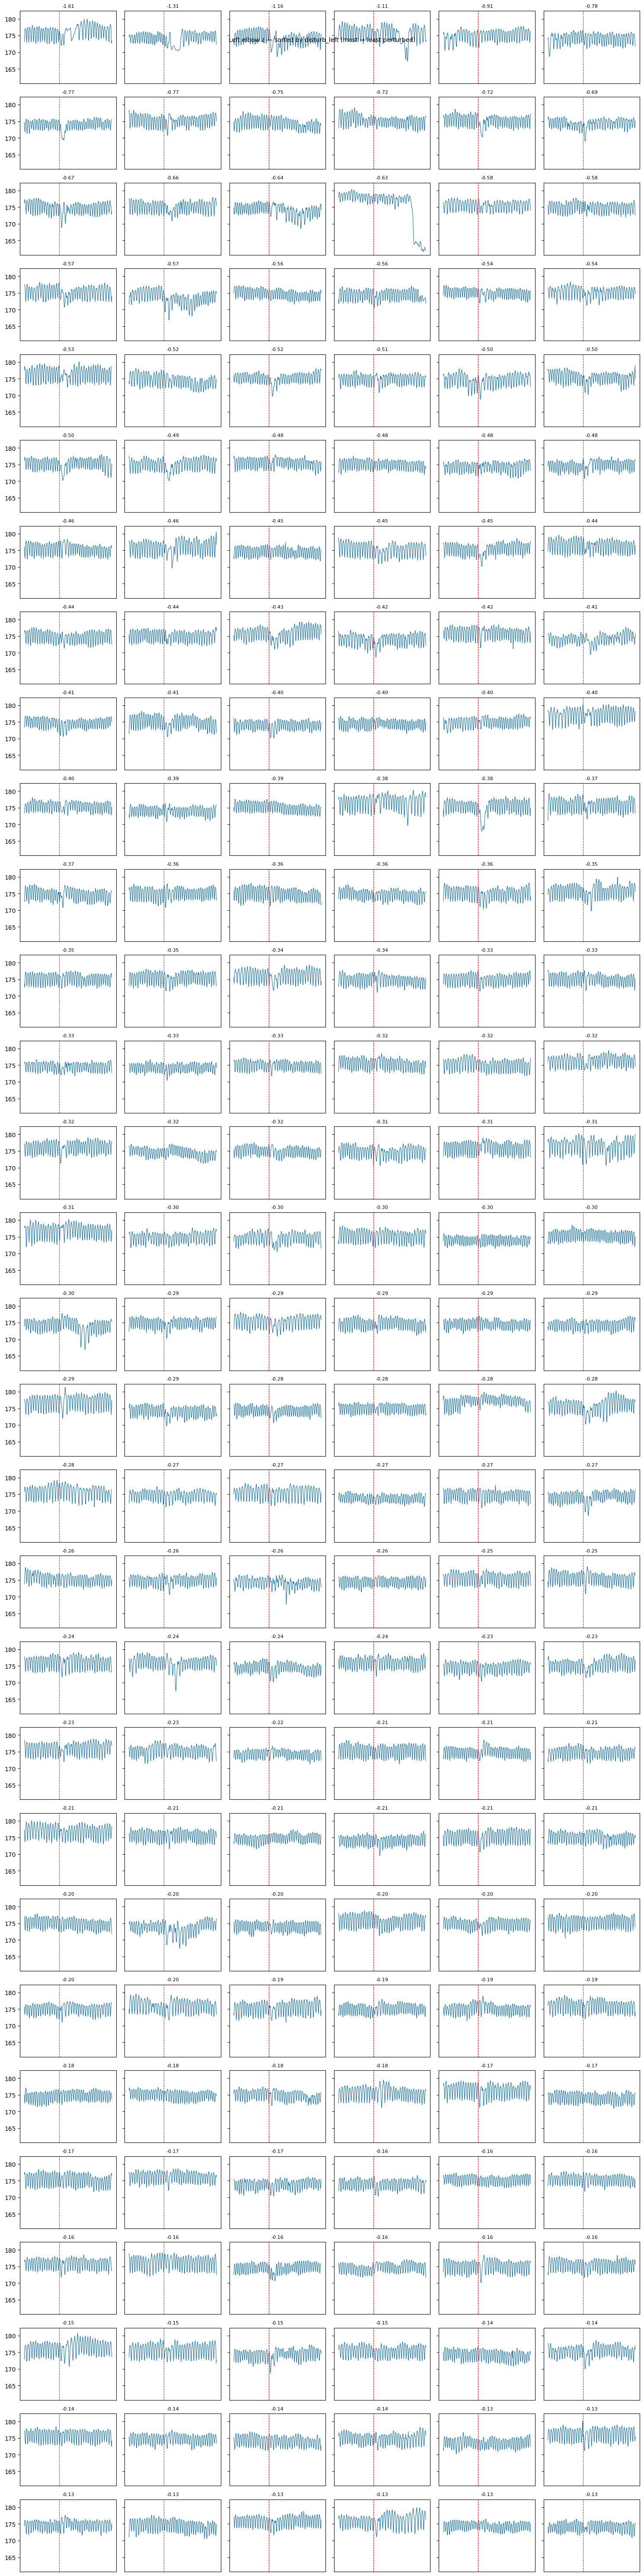

Plotted 180 trials | left_elbow z (bhv col 5)
disturb_left values: [-1.6098453  -1.31256102 -1.15773135 -1.10670154 -0.90774203 -0.78425244
 -0.77420578 -0.7678818  -0.75383209 -0.72052906 -0.71891068 -0.68932423
 -0.67394333 -0.65730424 -0.63734776 -0.62977144 -0.58358758 -0.5787942
 -0.56807485 -0.56655166 -0.56031024 -0.5585609  -0.54266856 -0.53804847
 -0.53002001 -0.52256234 -0.52117081 -0.50538533 -0.50335871 -0.50109505
 -0.49986895 -0.49405234 -0.48453947 -0.48368708 -0.4803228  -0.478691
 -0.46065716 -0.4555366  -0.4511037  -0.44869083 -0.44621598 -0.44251789
 -0.4368929  -0.43532128 -0.43083652 -0.42009769 -0.41897786 -0.41317172
 -0.41123794 -0.40947603 -0.40475894 -0.40346805 -0.40127573 -0.40024845
 -0.39724467 -0.38564388 -0.3850309  -0.38403697 -0.38097337 -0.37479502
 -0.37010124 -0.36179312 -0.36122061 -0.35867541 -0.35705414 -0.35284284
 -0.34890895 -0.34841278 -0.34408753 -0.33995403 -0.33481528 -0.33383469
 -0.33382889 -0.33333473 -0.32748044 -0.32237643 -0.32236802

In [196]:
# left_elbow z-component: keypoint index 1 → bhv column 1*3+2 = 5
LEFT_ELBOW_Z = 5
n_trials = len(perturb_td)
n_cols = 6
n_rows = int(np.ceil(n_trials / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.5, n_rows * 2), sharey=True)
axes = axes.flatten()

t = np.arange(perturb_td['bhv'].iloc[0].shape[0]) * perturb_td['bin_size'].iloc[0] * 1000  # ms

for i, (_, row) in enumerate(perturb_td.iterrows()):
    ax = axes[i]
    ax.plot(t, row['bhv'][:, LEFT_ELBOW_Z], lw=0.8)
    ax.axvline(row['idx_sol_on'] * row['bin_size'] * 1000, color='r', lw=0.8, ls='--')
    ax.set_title(f"{row['_disturb_left_mean']:.2f}", fontsize=8)
    ax.set_xticks([])

for ax in axes[n_trials:]:
    ax.set_visible(False)

fig.suptitle("Left elbow z — sorted by disturb_left (most → least perturbed)", fontsize=10)
fig.tight_layout()
plt.show()

print(f"Plotted {n_trials} trials | left_elbow z (bhv col {LEFT_ELBOW_Z})")
print(f"disturb_left values: {perturb_td['_disturb_left_mean'].values}")


In [234]:
perturb_td_shuff.head()

,index,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,...,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score,disturb_mean,disturb_sum,disturb_left,_disturb_left_mean
0,179,M103,M103_2026_02_18_15_30,754,trial,600,0.01,NaN,NaN,[],...,"[[194.14959626031128, 176.72861653768754, 188....",500,300,"[[1.107702578590213, 0.9538074952969856, 1.914...","[[1.782725281708161, -0.8351551037126035, 1.75...","[0.0441379013089247, -0.26912784028077974, 0.1...",-0.030372,-0.438344,"[-0.26912784028077974, -0.046643064669991186, ...",-0.126256
1,115,M103,M103_2026_02_18_15_30,238,trial,600,0.01,NaN,NaN,[],...,"[[194.00871518000292, 176.41680523336848, 188....",700,500,"[[1.7319813099574888, 0.4205314041243291, 2.18...","[[-1.4603120383181372, 1.6511890713907071, -1....","[-0.47138578395648323, -0.09282617609823123, -...",-0.335902,0.605394,"[-0.09282617609823123, -0.33279914505455716, -...",-0.238284
2,96,M103,M103_2026_02_18_15_30,180,trial,600,0.01,NaN,NaN,[],...,"[[207.75394691176268, 173.68241186106115, 205....",700,500,"[[1.9366519991447815, 1.1457216421738239, 2.31...","[[-1.79107156386413, 1.8630253219672763, -1.82...","[-0.11070729737569625, -0.1904643808815374, -0...",-0.206055,0.393165,"[-0.1904643808815374, -0.34866004140623685, -0...",-0.290136
3,24,M103,M103_2026_02_18_15_30,250,trial,600,0.01,NaN,NaN,[],...,"[[199.8598423364116, 177.8652615651632, 195.25...",700,500,"[[1.7467098455494938, 1.0001857648045378, 2.18...","[[1.5999878143092976, -1.4514986671944037, 1.5...","[-0.29374352328523434, -0.39567162795575384, -...",-0.380864,0.659952,"[-0.39567162795575384, -0.6093853522234634, -0...",-0.530020
4,9,M103,M103_2026_02_18_15_30,688,trial,600,0.01,NaN,NaN,[],...,"[[196.4749740029889, 178.71801085783744, 190.8...",500,300,"[[1.4633224491263503, 1.1233934901262654, 2.00...","[[1.6368390087882072, 1.480962926040827, 1.638...","[-0.3785547655199737, -0.7343376888515657, -0....",-0.451249,0.733598,"[-0.7343376888515657, -0.7485567100268595, -0....",-0.720529


In [295]:
### anchor the neural data instead of behaviour ####

area = 'MOp'
KEYPOINTS_LAG = ['left_knee', 'left_ankle', 'left_foot']

TIME_BINS_S = np.arange(-0.3, 0.7, 0.01)
LAGS_S = np.arange(-0.15, 0.16, 0.01)
BIN_SIZE = 0.01
WINDOW_S = 0.1
_perturb_bin = 200
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S / BIN_SIZE).astype(int)
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
cv = KFold(n_splits=5, shuffle=False)


def score_one_lag_anchored(neural_, bhv_, t, lag, model, cv, window_bins):
    """Fix neural window at time t, slide behavior by lag.
    Positive lag → neural at t predicts future kinematics (feedforward).
    Negative lag → neural at t predicts past kinematics (feedback).
    """
    # Fixed neural window
    X = neural_[:, t : t + window_bins, :].reshape(-1, neural_.shape[-1])
    # Slide behavior: shift_time_no_wrap(bhv, -lag)[t] == bhv[t + lag]
    bhv_shifted = dt.shift_time_no_wrap(bhv_, -lag)
    y = bhv_shifted[:, t : t + window_bins, :].reshape(-1, bhv_.shape[-1])
    cv_out = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer, n_jobs=1)
    return cv_out["test_score"]


pca_col = f"{area}_rates_pca"
n_pcs = 125
neural_data = np.stack(perturb_td_shuff[pca_col].values)[:, :, :n_pcs]
model = Ridge(alpha=1000)

results_anchored = {}  # {keypoint: {t_s + WINDOW_S: array(n_lags, n_folds)}}

for keypoint in tqdm(KEYPOINTS_LAG, desc='keypoints'):
    bhv_data = np.stack(perturb_td_shuff[keypoint].values)
    results_kp = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins):
        per_lag = Parallel(n_jobs=-1, prefer="processes")(
            delayed(score_one_lag_anchored)(neural_data, bhv_data, t, lag, model, cv, _window_bins)
            for lag in _lags_bins
        )
        results_kp[t_s + WINDOW_S] = np.stack(per_lag, axis=0)
    results_anchored[keypoint] = results_kp

print("Done.")

keypoints: 100%|██████████| 3/3 [01:21<00:00, 27.11s/it]

Done.


/tmp/ipykernel_1976937/291925104.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = mpl.cm.get_cmap('Blues', len(spaghetti_keys_an))


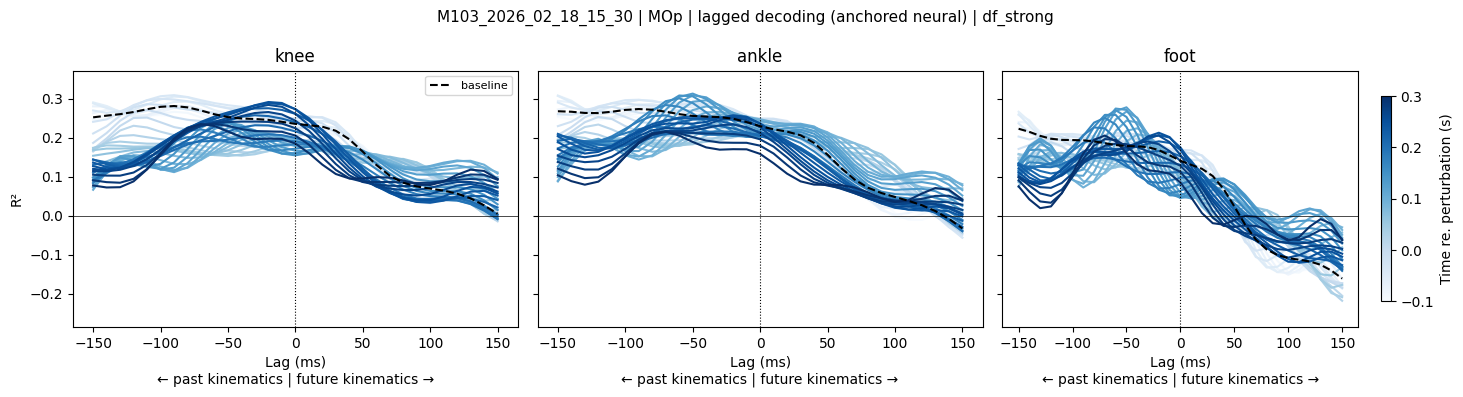

Baseline  : (-0.1, 0) s  (10 time bins)
Spaghetti : (-0.1, 0.3) s  (40 time bins)


In [296]:
# Visualisation windows
BASELINE_S  = (-0.1, 0)
SPAGHETTI_S = (-0.1,  0.3)

_all_t_an  = np.array(sorted(results_anchored[KEYPOINTS_LAG[0]].keys()))
_t_rel_an  = _all_t_an - WINDOW_S

baseline_keys_an  = _all_t_an[(_t_rel_an >= BASELINE_S[0])  & (_t_rel_an < BASELINE_S[1])]
spaghetti_keys_an = _all_t_an[(_t_rel_an >= SPAGHETTI_S[0]) & (_t_rel_an < SPAGHETTI_S[1])]
lags_ms = LAGS_S * 1000
cmap    = mpl.cm.get_cmap('Blues', len(spaghetti_keys_an))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, keypoint in zip(axes, KEYPOINTS_LAG):
    res = results_anchored[keypoint]
    baseline = np.stack([res[k].mean(axis=1) for k in baseline_keys_an]).mean(axis=0)

    for i, k in enumerate(spaghetti_keys_an):
        vizutils.shaded_errorbar(ax, lags_ms, res[k], errorStat=scipy.stats.sem,
                                 alpha_err=0, color=cmap(i))

    ax.plot(lags_ms, baseline, color='k', lw=1.5, ls='--', zorder=10, label='baseline')
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Lag (ms)\n← past kinematics | future kinematics →')
    ax.set_title(keypoint.replace('left_', ''))

axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8)
# axes[0].set_ylim(-0.2, 0.35)

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=mpl.colors.Normalize(SPAGHETTI_S[0], SPAGHETTI_S[1]))
sm.set_array([])
plt.colorbar(sm, ax=axes[-1], label='Time re. perturbation (s)', shrink=0.8)

fig.suptitle(f'{perturb_td_shuff.session.values[0]} | {area} | lagged decoding (anchored neural) | df_strong', fontsize=11)
fig.tight_layout()
plt.show()

print(f"Baseline  : {BASELINE_S} s  ({len(baseline_keys_an)} time bins)")
print(f"Spaghetti : {SPAGHETTI_S} s  ({len(spaghetti_keys_an)} time bins)")

left_knee    | peak R² range: 0.187 – 0.309  |  peak lag range: -130.0 – 0.0 ms
left_ankle   | peak R² range: 0.215 – 0.313  |  peak lag range: -150.0 – 10.0 ms
left_foot    | peak R² range: 0.149 – 0.278  |  peak lag range: -150.0 – -20.0 ms


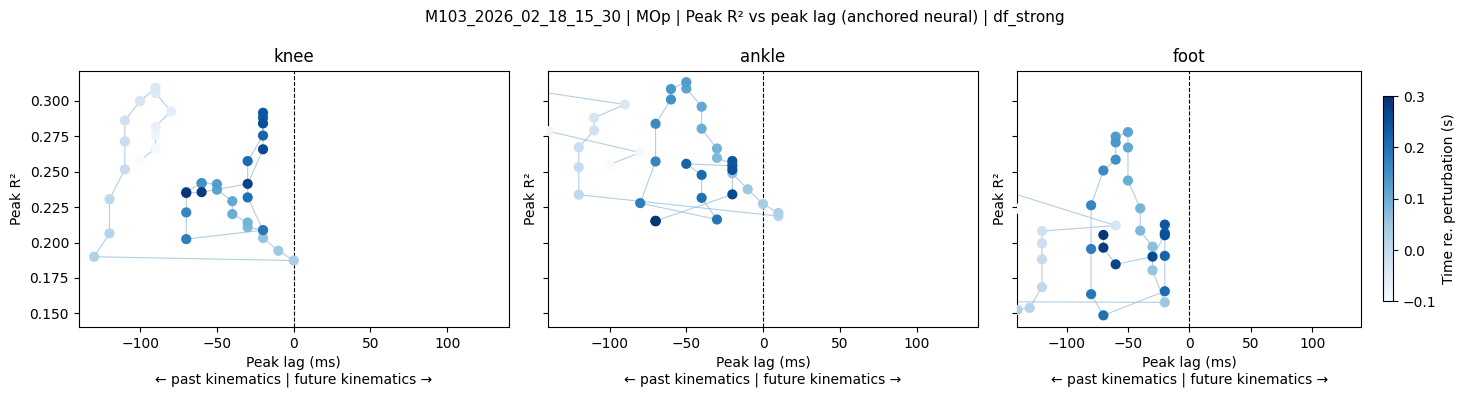

In [297]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True, sharex=True)

for ax, keypoint in zip(axes, KEYPOINTS_LAG):
    res = results_anchored[keypoint]
    peak_lags = []
    peak_r2   = []
    times     = []

    for k in spaghetti_keys_an:
        curve = res[k].mean(axis=1)
        idx = curve.argmax()
        peak_lags.append(lags_ms[idx])
        peak_r2.append(curve[idx])
        times.append(k - WINDOW_S)

    times     = np.array(times)
    peak_lags = np.array(peak_lags)
    peak_r2   = np.array(peak_r2)

    # connect dots in temporal order
    ax.plot(peak_lags, peak_r2, color='steelblue', lw=0.8, alpha=0.4, zorder=2)
    sc = ax.scatter(peak_lags, peak_r2, c=times, cmap='Blues',
                    vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1], s=40, zorder=3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Peak lag (ms)\n← past kinematics | future kinematics →')
    ax.set_ylabel('Peak R²')
    ax.set_title(keypoint.replace('left_', ''))
    ax.set_xlim(-140, 140)

    print(f"{keypoint:12s} | peak R² range: {peak_r2.min():.3f} – {peak_r2.max():.3f}"
          f"  |  peak lag range: {peak_lags.min():.1f} – {peak_lags.max():.1f} ms")

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=mpl.colors.Normalize(SPAGHETTI_S[0], SPAGHETTI_S[1]))
sm.set_array([])
plt.colorbar(sm, ax=axes[-1], label='Time re. perturbation (s)', shrink=0.8)

fig.suptitle(f'{perturb_td_shuff.session.values[0]} | {area} | Peak R² vs peak lag (anchored neural) | df_strong', fontsize=11)
fig.tight_layout()
plt.show()

left_knee    | 40/40 fits succeeded  |  peak lag range: -83.2 – -2.6 ms
left_ankle   | 40/40 fits succeeded  |  peak lag range: -88.2 – -17.1 ms
left_foot    | 40/40 fits succeeded  |  peak lag range: -111.7 – -51.6 ms


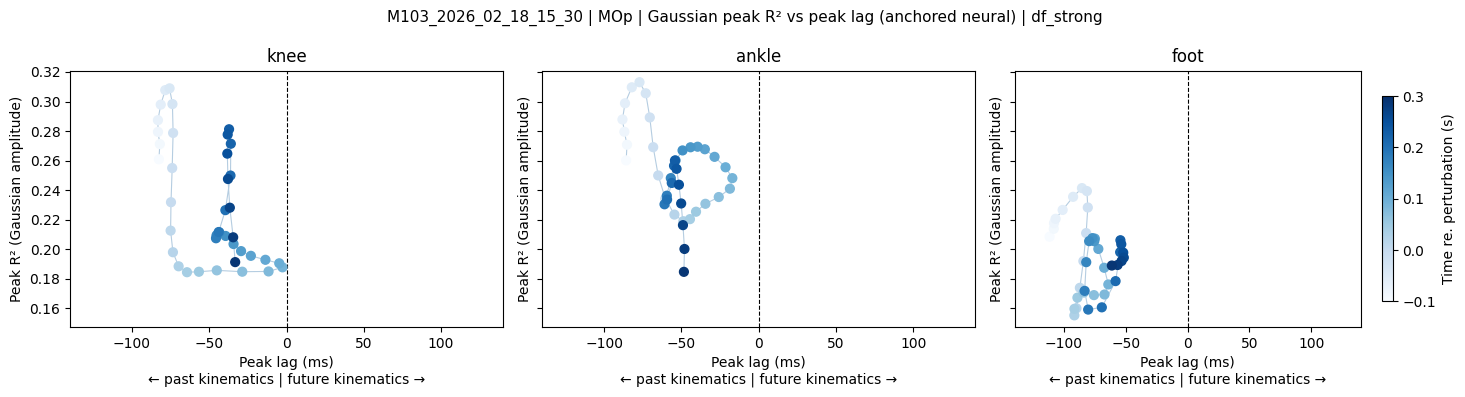

In [298]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, keypoint in zip(axes, KEYPOINTS_LAG):
    res = results_anchored[keypoint]
    peak_lags = []
    peak_r2   = []
    times     = []

    for k in spaghetti_keys_an:
        curve = res[k].mean(axis=1)
        t_rel = k - WINDOW_S
        try:
            bounds = ([0, lags_ms[0], 5], [1, lags_ms[-1], 300])
            p0 = [np.clip(curve.max(), 0, 1), lags_ms[curve.argmax()], 30.0]
            popt, _ = curve_fit(gaussian, lags_ms, curve, p0=p0, bounds=bounds, maxfev=5000)
            peak_lags.append(popt[1])
            peak_r2.append(popt[0])
        except (RuntimeError, ValueError):
            peak_lags.append(np.nan)
            peak_r2.append(np.nan)
        times.append(t_rel)

    times     = np.array(times)
    peak_lags = np.array(peak_lags)
    peak_r2   = np.array(peak_r2)

    valid = ~np.isnan(peak_lags)
    ax.plot(peak_lags[valid], peak_r2[valid], color='steelblue', lw=0.8, alpha=0.4, zorder=2)
    sc = ax.scatter(peak_lags[valid], peak_r2[valid], c=times[valid], cmap='Blues',
                    vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1], s=40, zorder=3)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('Peak lag (ms)\n← past kinematics | future kinematics →')
    ax.set_ylabel('Peak R² (Gaussian amplitude)')
    ax.set_title(keypoint.replace('left_', ''))
    ax.set_xlim(-140, 140)


    print(f"{keypoint:12s} | {valid.sum()}/{len(times)} fits succeeded"
          f"  |  peak lag range: {np.nanmin(peak_lags):.1f} – {np.nanmax(peak_lags):.1f} ms")

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=mpl.colors.Normalize(SPAGHETTI_S[0], SPAGHETTI_S[1]))
sm.set_array([])
plt.colorbar(sm, ax=axes[-1], label='Time re. perturbation (s)', shrink=0.8)

fig.suptitle(f'{perturb_td_shuff.session.values[0]} | {area} | Gaussian peak R² vs peak lag (anchored neural) | df_strong', fontsize=11)
fig.tight_layout()
plt.show()

# Pipeline

In [21]:
# ---------------------------------------------------------------------------
# Parameters — adjust as needed
# ---------------------------------------------------------------------------
AREAS_RUN      = ['MOp', 'CP']
FORELIMB_KPS   = ['left_elbow', 'left_paw', 'left_wrist']
HINDLIMB_KPS   = ['left_ankle', 'left_knee', 'left_foot']
ALL_KPS_RUN    = FORELIMB_KPS + HINDLIMB_KPS

N_PCS          = {'MOp': 25, 'CP': 30}   # PCs per area (base)
PC_MULTIPLIERS = [1, 4]                   # run once with base, once with 4x
ALPHA          = 1000                     # Ridge regularisation
TIME_BINS_S_R  = np.arange(-0.6, 0.7, 0.01)
LAGS_S_R       = np.arange(-0.15, 0.16, 0.01)
BIN_SIZE_R     = 0.01
WINDOW_S_R     = 0.01
# ---------------------------------------------------------------------------

_perturb_bin_r  = 200
_time_bins_r    = (np.round(TIME_BINS_S_R / BIN_SIZE_R) + _perturb_bin_r).astype(int)
_window_bins_r  = int(round(WINDOW_S_R / BIN_SIZE_R))
_lags_bins_r    = np.round(LAGS_S_R / BIN_SIZE_R).astype(int)
_lags_ms_r      = LAGS_S_R * 1000

vw_r2_scorer_r = make_scorer(r2_score, multioutput="variance_weighted")
cv_r           = KFold(n_splits=5, shuffle=False)


def score_one_lag_anchored_r(neural_, bhv_, t, lag, model, cv, window_bins):
    X           = neural_[:, t : t + window_bins, :].reshape(-1, neural_.shape[-1])
    bhv_shifted = dt.shift_time_no_wrap(bhv_, -lag)
    y           = bhv_shifted[:, t : t + window_bins, :].reshape(-1, bhv_.shape[-1])
    cv_out      = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer_r, n_jobs=1)
    return cv_out["test_score"]


# results_pipeline[pc_mult][area][keypoint][t_s + WINDOW_S_R] → array(n_lags, n_folds)
results_pipeline = {}

for pc_mult in PC_MULTIPLIERS:
    results_pipeline[pc_mult] = {}
    for area in AREAS_RUN:
        pca_col = f"{area}_rates_pca"
        if pca_col not in perturb_td_shuff.columns:
            print(f"Skipping {area} — {pca_col} not found")
            continue

        n_pcs_area  = min(N_PCS[area] * pc_mult, perturb_td_shuff[pca_col].iloc[0].shape[-1])
        neural_data = np.stack(perturb_td_shuff[pca_col].values)[:, :, :n_pcs_area]
        model_r     = Ridge(alpha=ALPHA)
        results_pipeline[pc_mult][area] = {}

        print(f"\n[x{pc_mult}] {area} | {n_pcs_area} PCs")
        for keypoint in tqdm(ALL_KPS_RUN, desc=f"{area} x{pc_mult}"):
            if keypoint not in perturb_td_shuff.columns:
                print(f"  Skipping {keypoint} — not in dataframe")
                continue

            bhv_data   = np.stack(perturb_td_shuff[keypoint].values)
            results_kp = {}
            for t_s, t in zip(TIME_BINS_S_R, _time_bins_r):
                per_lag = Parallel(n_jobs=-1, prefer="processes")(
                    delayed(score_one_lag_anchored_r)(
                        neural_data, bhv_data, t, lag, model_r, cv_r, _window_bins_r
                    )
                    for lag in _lags_bins_r
                )
                results_kp[t_s + WINDOW_S_R] = np.stack(per_lag, axis=0)
            results_pipeline[pc_mult][area][keypoint] = results_kp

print("\nDone.")


[x1] MOp | 25 PCs


MOp x1: 100%|██████████| 6/6 [02:18<00:00, 23.13s/it]



[x1] CP | 30 PCs


CP x1: 100%|██████████| 6/6 [02:12<00:00, 22.03s/it]



[x4] MOp | 100 PCs


MOp x4: 100%|██████████| 6/6 [02:22<00:00, 23.70s/it]



[x4] CP | 120 PCs


CP x4: 100%|██████████| 6/6 [02:30<00:00, 25.11s/it]


Done.


[autoreload of tools.subspaces.communication failed: Traceback (most recent call last):
  File "/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/data/poetryenvs/earthquake-analysis-Z8riI-lB-py3.12/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/data/miniconda3/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 999, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/home/me24/repos/earthquake-analysis/notebooks/pipelines/encoding_decoding/../../../tools/subspaces/communication.py", line 4, in <module>
    from .utils import variance_in_subs

Baseline  : (-0.4, -0.1)  (30 bins)
Spaghetti : (-0.5, 0.5)  (100 bins)


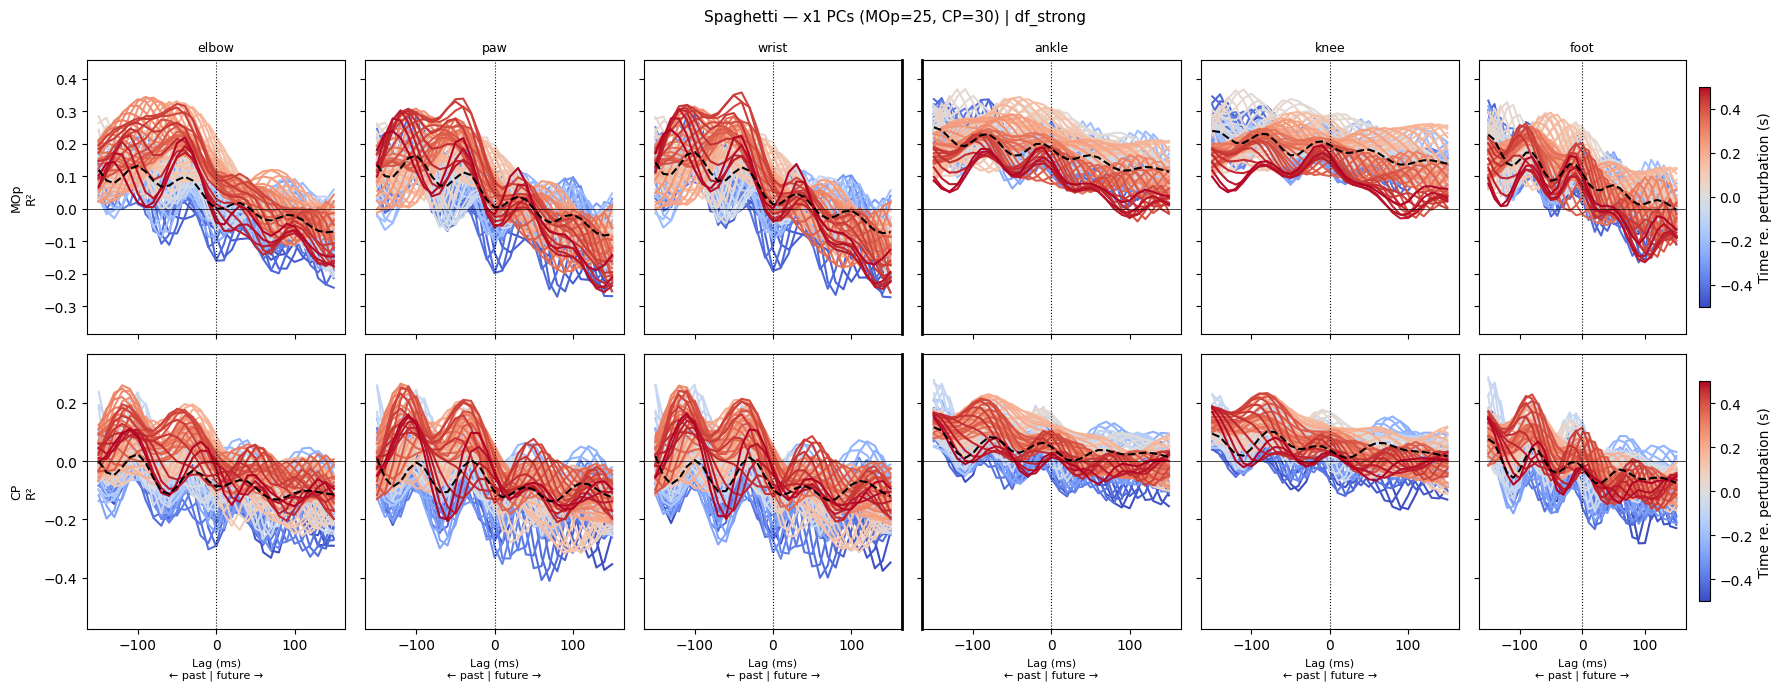

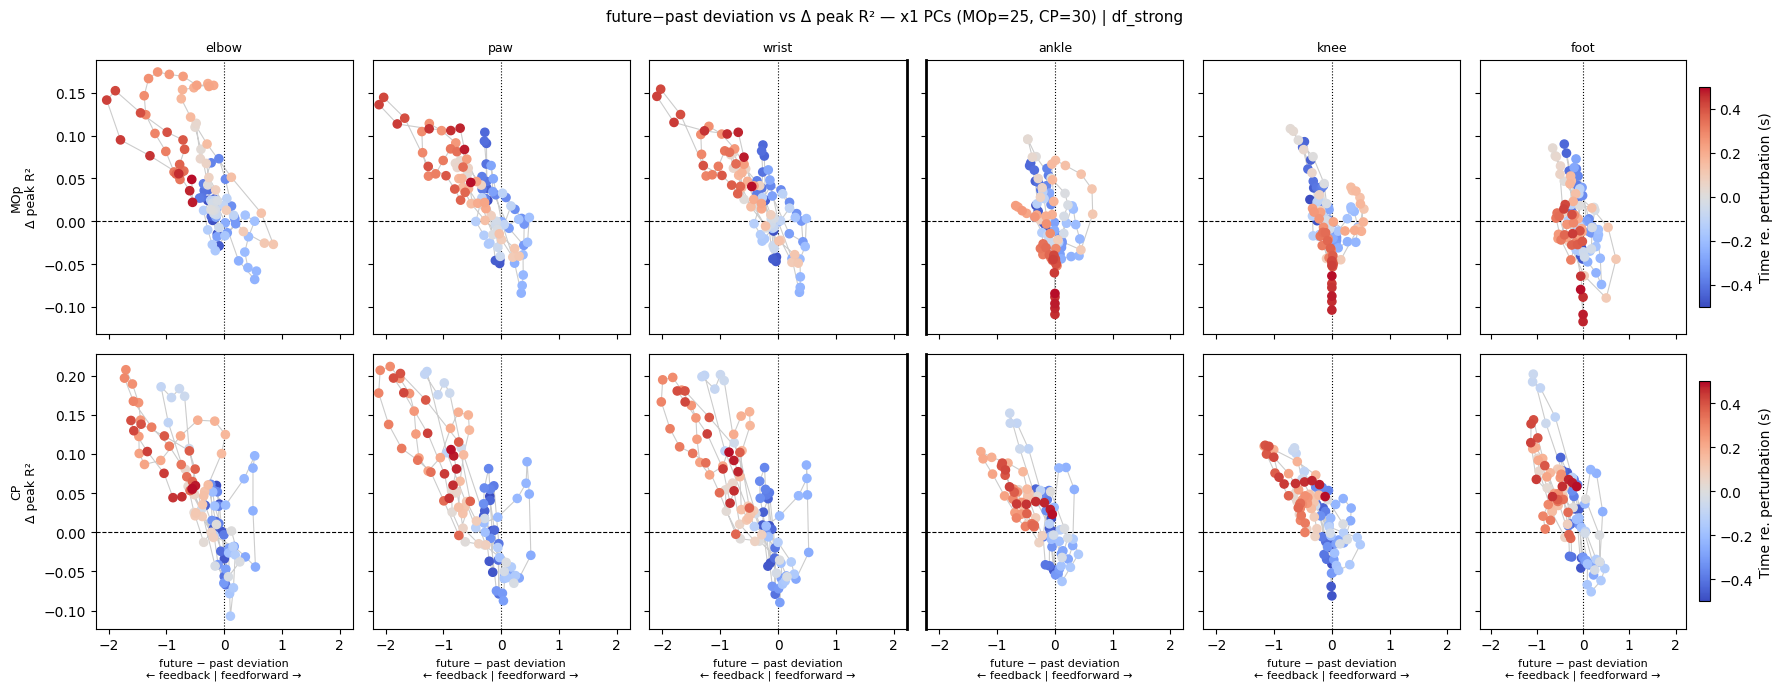

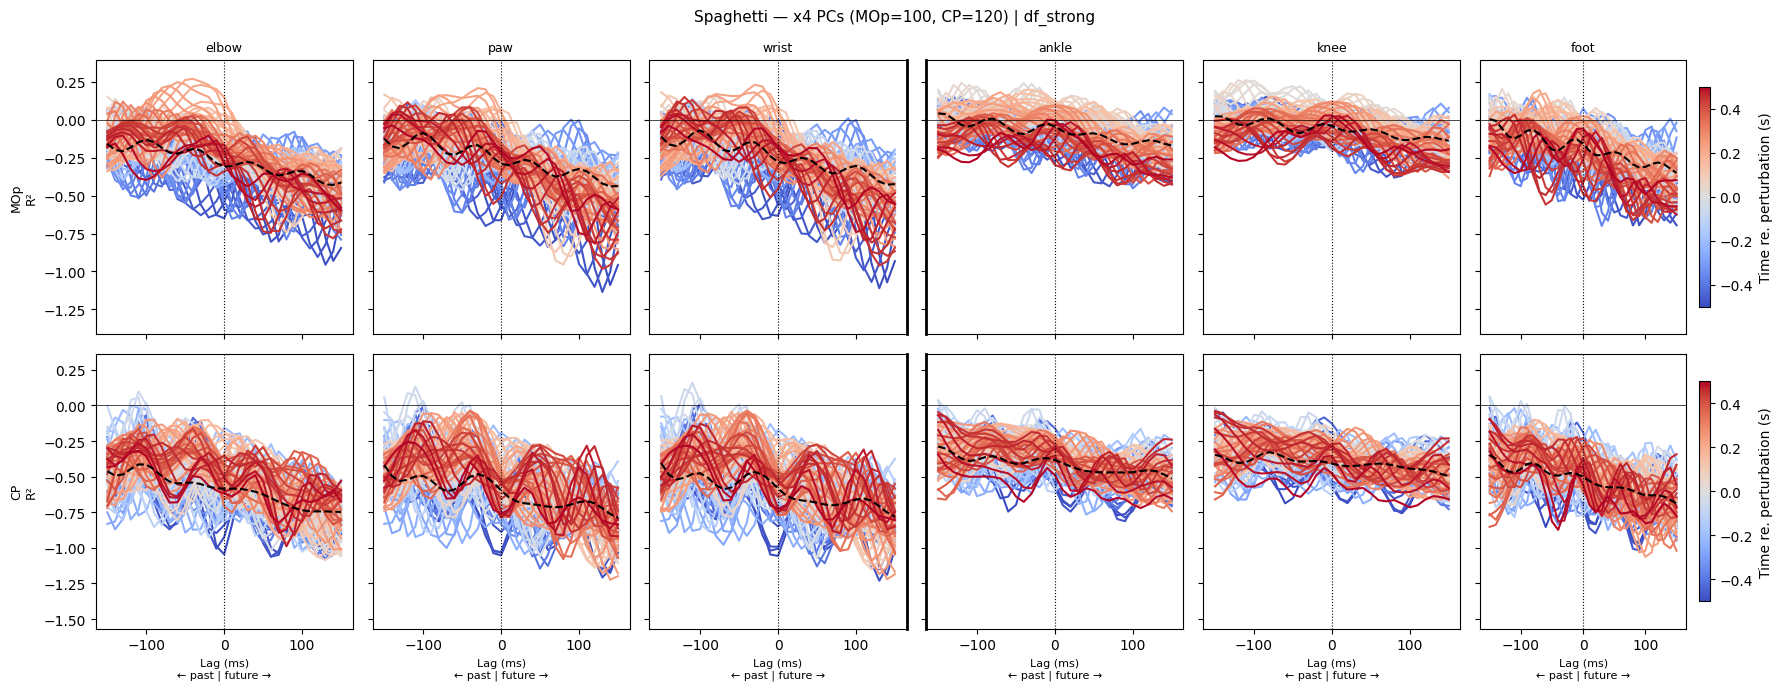

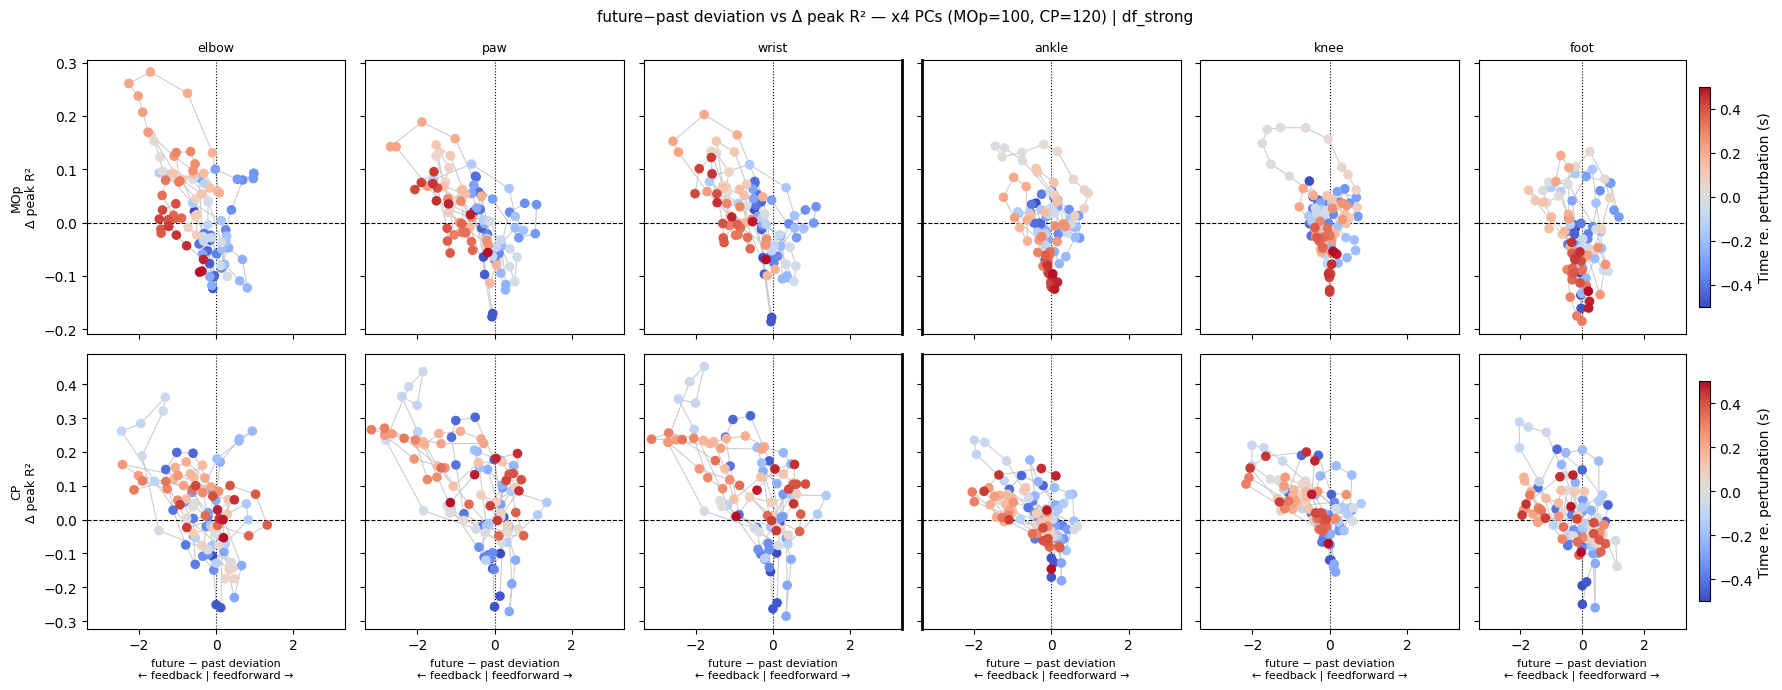

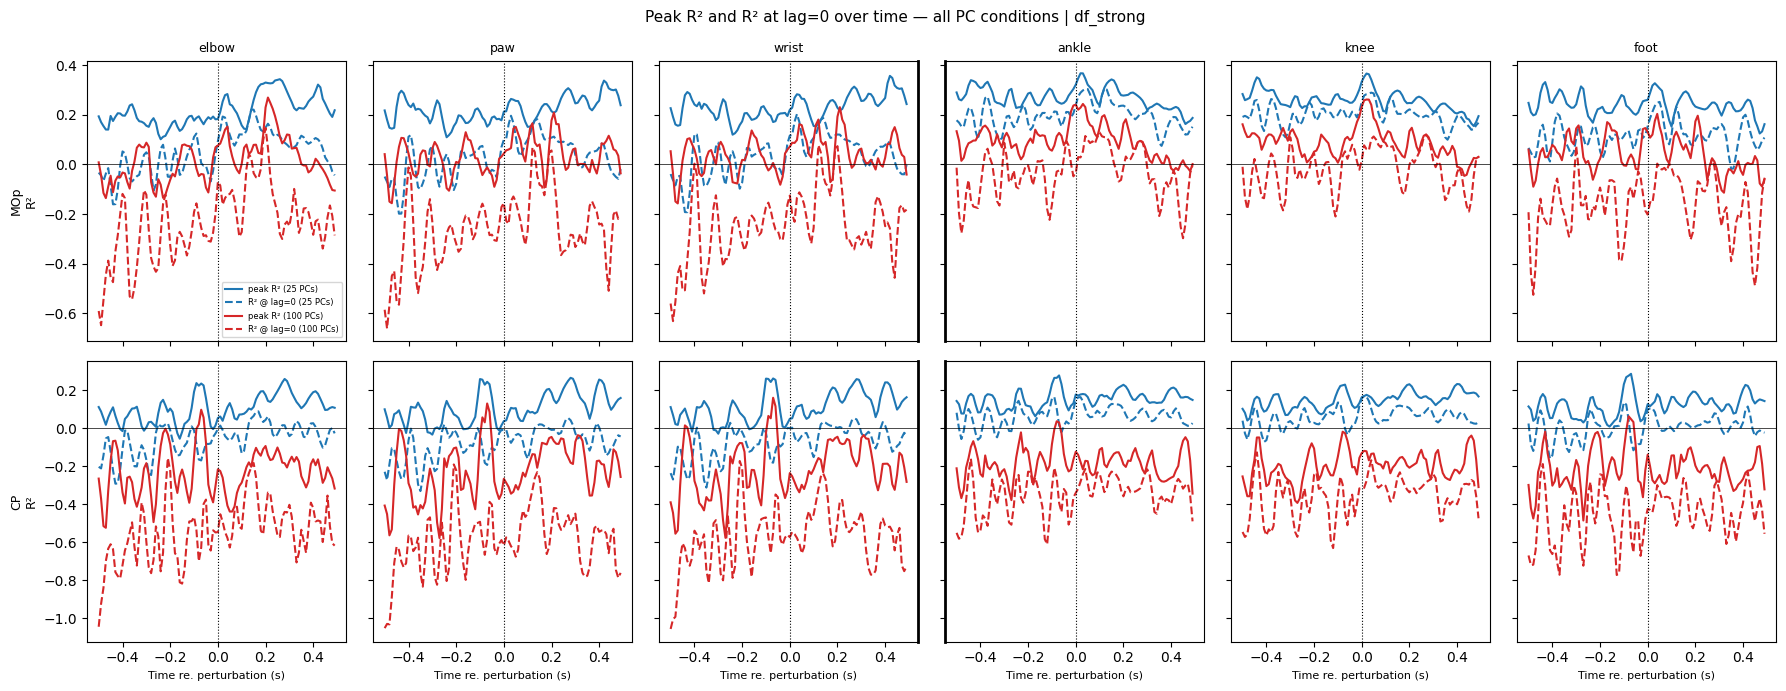

In [22]:
# ---------------------------------------------------------------------------
# Visualization parameters
# ---------------------------------------------------------------------------
BASELINE_P   = (-0.4, -0.1)   # baseline window (s re. perturbation)
SPAGHETTI_P  = (-0.5,  0.5)   # spaghetti window — symmetric around perturbation
# ---------------------------------------------------------------------------

# Build time keys from the first available entry
_p_first_mult = PC_MULTIPLIERS[0]
_p_first_area = next(a for a in AREAS_RUN if a in results_pipeline[_p_first_mult])
_p_first_kp   = next(k for k in ALL_KPS_RUN if k in results_pipeline[_p_first_mult][_p_first_area])
_p_all_t      = np.array(sorted(results_pipeline[_p_first_mult][_p_first_area][_p_first_kp].keys()))
_p_t_rel      = _p_all_t - WINDOW_S_R

_p_baseline_keys  = _p_all_t[(_p_t_rel >= BASELINE_P[0])  & (_p_t_rel < BASELINE_P[1])]
_p_spaghetti_keys = _p_all_t[(_p_t_rel >= SPAGHETTI_P[0]) & (_p_t_rel < SPAGHETTI_P[1])]
_p_spag_times     = _p_spaghetti_keys - WINDOW_S_R
_p_t0_idx         = np.argmin(np.abs(_lags_ms_r))

_p_norm_cw   = mpl.colors.Normalize(SPAGHETTI_P[0], SPAGHETTI_P[1])
_p_cmap_spag = mpl.cm.get_cmap('coolwarm', len(_p_spaghetti_keys))
_pc_colors   = {pc_mult: c for pc_mult, c in zip(PC_MULTIPLIERS, ['tab:blue', 'tab:red'])}

print(f"Baseline  : {BASELINE_P}  ({len(_p_baseline_keys)} bins)")
print(f"Spaghetti : {SPAGHETTI_P}  ({len(_p_spaghetti_keys)} bins)")

n_areas = len(AREAS_RUN)
n_kps   = len(ALL_KPS_RUN)


def _plot_spaghetti(results_pc, pc_mult, title_suffix):
    fig, axes = plt.subplots(n_areas, n_kps, figsize=(3 * n_kps, 3.5 * n_areas),
                              sharey='row', sharex=True)
    if n_areas == 1:
        axes = axes[np.newaxis, :]

    for i_area, area in enumerate(AREAS_RUN):
        if area not in results_pc:
            continue
        for i_kp, keypoint in enumerate(ALL_KPS_RUN):
            ax = axes[i_area, i_kp]
            if keypoint not in results_pc[area]:
                ax.set_visible(False)
                continue

            res      = results_pc[area][keypoint]
            baseline = np.stack([res[k].mean(axis=1) for k in _p_baseline_keys]).mean(axis=0)

            for i, k in enumerate(_p_spaghetti_keys):
                vizutils.shaded_errorbar(ax, _lags_ms_r, res[k], errorStat=scipy.stats.sem,
                                         alpha_err=0, color=_p_cmap_spag(i))
            ax.plot(_lags_ms_r, baseline, color='k', lw=1.5, ls='--', zorder=10)
            ax.axvline(0, color='k', lw=0.8, ls=':')
            ax.axhline(0, color='k', lw=0.5)

            if i_area == 0:
                ax.set_title(keypoint.replace('left_', ''), fontsize=9)
            if i_kp == 0:
                ax.set_ylabel(f'{area}\nR²', fontsize=9)
            if i_area == n_areas - 1:
                ax.set_xlabel('Lag (ms)\n← past | future →', fontsize=8)

        sm = mpl.cm.ScalarMappable(cmap='coolwarm', norm=_p_norm_cw)
        sm.set_array([])
        plt.colorbar(sm, ax=axes[i_area, -1], label='Time re. perturbation (s)', shrink=0.8)

    for i_area in range(n_areas):
        axes[i_area, len(FORELIMB_KPS) - 1].spines['right'].set_linewidth(2)
        axes[i_area, len(FORELIMB_KPS)].spines['left'].set_linewidth(2)

    fig.suptitle(f'Spaghetti — {title_suffix} | df_strong', fontsize=11)
    fig.tight_layout()
    plt.show()


def _plot_deviation(results_pc, pc_mult, title_suffix):
    fig, axes = plt.subplots(n_areas, n_kps, figsize=(3 * n_kps, 3.5 * n_areas),
                              sharey='row', sharex=True)
    if n_areas == 1:
        axes = axes[np.newaxis, :]

    all_asym = []

    for i_area, area in enumerate(AREAS_RUN):
        if area not in results_pc:
            continue
        for i_kp, keypoint in enumerate(ALL_KPS_RUN):
            if keypoint not in results_pc[area]:
                continue

            res      = results_pc[area][keypoint]
            baseline = np.stack([res[k].mean(axis=1) for k in _p_baseline_keys]).mean(axis=0)
            baseline_peak_r2 = np.mean([res[k].mean(axis=1).max() for k in _p_baseline_keys])

            asymmetry, peak_r2s = [], []
            for k in _p_spaghetti_keys:
                curve      = res[k].mean(axis=1)
                past_dev   = np.sum(np.maximum(curve[:_p_t0_idx] - baseline[:_p_t0_idx], 0))
                future_dev = np.sum(np.maximum(curve[_p_t0_idx:] - baseline[_p_t0_idx:], 0))
                asymmetry.append(future_dev - past_dev)
                peak_r2s.append(curve.max())

            asymmetry = np.array(asymmetry)
            r2_shift  = np.array(peak_r2s) - baseline_peak_r2
            all_asym.append(np.abs(asymmetry).max())

            ax = axes[i_area, i_kp]
            ax.plot(asymmetry, r2_shift, color='grey', lw=0.8, alpha=0.4, zorder=2)
            ax.scatter(asymmetry, r2_shift, c=_p_spag_times, cmap='coolwarm',
                       norm=_p_norm_cw, s=35, zorder=3)
            ax.axhline(0, color='k', lw=0.8, ls='--')
            ax.axvline(0, color='k', lw=0.8, ls=':')

            if i_area == 0:
                ax.set_title(keypoint.replace('left_', ''), fontsize=9)
            if i_kp == 0:
                ax.set_ylabel(f'{area}\nΔ peak R²', fontsize=9)
            if i_area == n_areas - 1:
                ax.set_xlabel('future − past deviation\n← feedback | feedforward →', fontsize=8)

        sm2 = mpl.cm.ScalarMappable(cmap='coolwarm', norm=_p_norm_cw)
        sm2.set_array([])
        plt.colorbar(sm2, ax=axes[i_area, -1], label='Time re. perturbation (s)', shrink=0.8)

    for i_area in range(n_areas):
        axes[i_area, len(FORELIMB_KPS) - 1].spines['right'].set_linewidth(2)
        axes[i_area, len(FORELIMB_KPS)].spines['left'].set_linewidth(2)

    x_lim = max(all_asym) * 1.05 if all_asym else 1.0
    for ax in axes.flat:
        if ax.get_visible():
            ax.set_xlim(-x_lim, x_lim)

    fig.suptitle(f'future−past deviation vs Δ peak R² — {title_suffix} | df_strong', fontsize=11)
    fig.tight_layout()
    plt.show()


def _plot_r2_over_time(results_all_mults, title_suffix):
    """One panel per (area, keypoint).
    Solid line  = peak R² (max of curve) over time.
    Dashed line = R² at lag=0 over time.
    Color = PC multiplier (blue=1x, red=4x).
    """
    fig, axes = plt.subplots(n_areas, n_kps, figsize=(3 * n_kps, 3.5 * n_areas),
                              sharey='row', sharex=True)
    if n_areas == 1:
        axes = axes[np.newaxis, :]

    for i_area, area in enumerate(AREAS_RUN):
        for i_kp, keypoint in enumerate(ALL_KPS_RUN):
            ax = axes[i_area, i_kp]

            any_plotted = False
            for pc_mult in PC_MULTIPLIERS:
                if area not in results_all_mults.get(pc_mult, {}):
                    continue
                if keypoint not in results_all_mults[pc_mult][area]:
                    continue

                res       = results_all_mults[pc_mult][area][keypoint]
                peak_r2   = np.array([res[k].mean(axis=1).max()      for k in _p_spaghetti_keys])
                r2_lag0   = np.array([res[k].mean(axis=1)[_p_t0_idx] for k in _p_spaghetti_keys])
                n_pcs_lbl = N_PCS[area] * pc_mult
                color     = _pc_colors[pc_mult]

                ax.plot(_p_spag_times, peak_r2,  color=color, lw=1.5,
                        label=f'peak R² ({n_pcs_lbl} PCs)')
                ax.plot(_p_spag_times, r2_lag0,  color=color, lw=1.5, ls='--',
                        label=f'R² @ lag=0 ({n_pcs_lbl} PCs)')
                any_plotted = True

            if not any_plotted:
                ax.set_visible(False)
                continue

            ax.axvline(0, color='k', lw=0.8, ls=':')
            ax.axhline(0, color='k', lw=0.5)

            if i_area == 0:
                ax.set_title(keypoint.replace('left_', ''), fontsize=9)
            if i_kp == 0:
                ax.set_ylabel(f'{area}\nR²', fontsize=9)
            if i_area == n_areas - 1:
                ax.set_xlabel('Time re. perturbation (s)', fontsize=8)
            if i_area == 0 and i_kp == 0:
                ax.legend(fontsize=6)

    for i_area in range(n_areas):
        axes[i_area, len(FORELIMB_KPS) - 1].spines['right'].set_linewidth(2)
        axes[i_area, len(FORELIMB_KPS)].spines['left'].set_linewidth(2)

    fig.suptitle(f'Peak R² and R² at lag=0 over time — {title_suffix} | df_strong', fontsize=11)
    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Plot for each PC multiplier (spaghetti + deviation)
# ---------------------------------------------------------------------------
for pc_mult in PC_MULTIPLIERS:
    n_pcs_info = {a: min(N_PCS[a] * pc_mult, perturb_td_shuff[f"{a}_rates_pca"].iloc[0].shape[-1])
                  for a in AREAS_RUN if f"{a}_rates_pca" in perturb_td_shuff.columns}
    suffix = f"x{pc_mult} PCs ({', '.join(f'{a}={v}' for a, v in n_pcs_info.items())})"
    _plot_spaghetti(results_pipeline[pc_mult], pc_mult, suffix)
    _plot_deviation(results_pipeline[pc_mult], pc_mult, suffix)

# R² metrics over time — both PC conditions overlaid
_plot_r2_over_time(results_pipeline, 'all PC conditions')

left_elbow   | peak lag range: -150.0 to -10.0 ms
left_paw     | peak lag range: -150.0 to -10.0 ms
left_wrist   | peak lag range: -150.0 to -10.0 ms


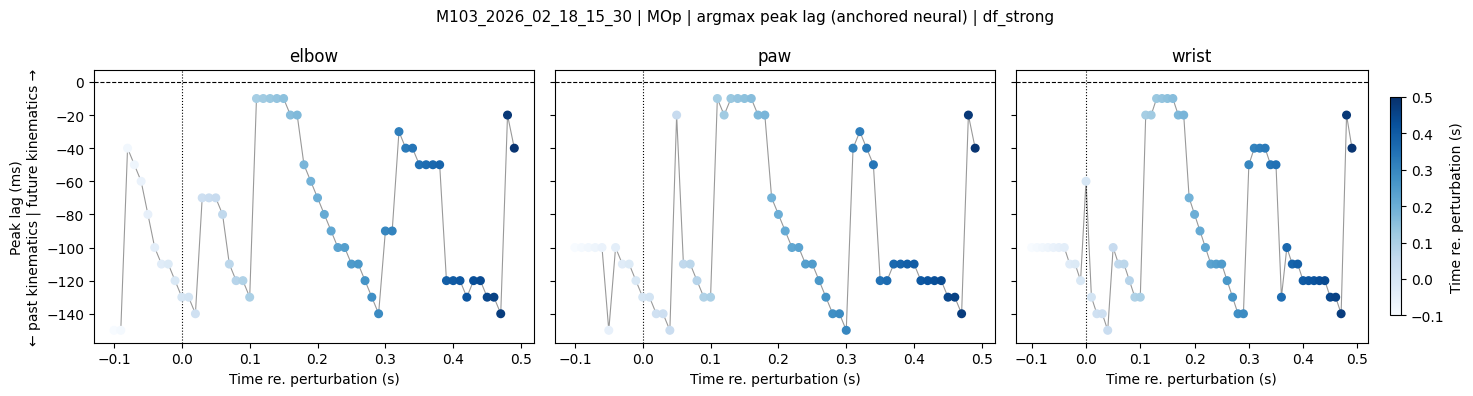

In [285]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, keypoint in zip(axes, KEYPOINTS_LAG):
    res = results_anchored[keypoint]
    peak_lags = []
    times = []

    for k in spaghetti_keys_an:
        curve = res[k].mean(axis=1)
        peak_lags.append(lags_ms[curve.argmax()])
        times.append(k - WINDOW_S)

    times = np.array(times)
    peak_lags = np.array(peak_lags)

    ax.scatter(times, peak_lags, c=times, cmap='Blues',
               vmin=SPAGHETTI_S[0], vmax=SPAGHETTI_S[1], s=30, zorder=3)
    ax.plot(times, peak_lags, color='k', lw=0.8, alpha=0.4)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(keypoint.replace('left_', ''))

    print(f"{keypoint:12s} | peak lag range: {peak_lags.min():.1f} to {peak_lags.max():.1f} ms")

axes[0].set_ylabel('Peak lag (ms)\n← past kinematics | future kinematics →')

sm = mpl.cm.ScalarMappable(cmap='Blues', norm=mpl.colors.Normalize(SPAGHETTI_S[0], SPAGHETTI_S[1]))
sm.set_array([])
plt.colorbar(sm, ax=axes[-1], label='Time re. perturbation (s)', shrink=0.8)

fig.suptitle(f'{perturb_td_shuff.session.values[0]} | {area} | argmax peak lag (anchored neural) | df_strong', fontsize=11)
fig.tight_layout()
plt.show()

In [230]:
area = 'MOp'
KEYPOINTS_LAG = ['left_knee', 'left_foot', 'left_ankle']
KEYPOINTS_LAG = ['left_elbow', 'left_paw', 'left_wrist']

TIME_BINS_S = np.arange(-1, 1, 0.02)
LAGS_S = np.arange(-0.15, 0.16, 0.01)
BIN_SIZE = 0.01
WINDOW_S = 0.2
_perturb_bin = 200
_time_bins   = (np.round(TIME_BINS_S / BIN_SIZE) + _perturb_bin).astype(int)
_window_bins = int(round(WINDOW_S / BIN_SIZE))
_lags_bins   = np.round(LAGS_S / BIN_SIZE).astype(int)
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")
cv = KFold(n_splits=5, shuffle=False)

def score_one_lag(arr_, t, lag, y, model, cv, window_bins):
    arr = dt.shift_time_no_wrap(arr_, lag)
    arr = arr[:, t : t + window_bins, :]
    X = arr.reshape(-1, arr.shape[-1])
    cv_out = cross_validate(model, X, y, cv=cv, scoring=vw_r2_scorer, n_jobs=1)
    return cv_out["test_score"]

pca_col = f"{area}_rates_pca"
n_pcs = 25
neural_data = np.stack(perturb_td_shuff[pca_col].values)[:, :, :n_pcs]
model = Ridge(alpha=1000)

results = {}  # {keypoint: {t_s + WINDOW_S: array(n_lags, n_folds)}}

for keypoint in tqdm(KEYPOINTS_LAG, desc='keypoints'):
    power_ = np.stack(perturb_td_shuff[keypoint].values)
    results_kp = {}
    for t_s, t in zip(TIME_BINS_S, _time_bins):
        y = power_[:, t : t + _window_bins, :].reshape(-1, power_.shape[-1])
        per_lag = Parallel(n_jobs=-1, prefer="processes")(
            delayed(score_one_lag)(neural_data, t, lag, y, model, cv, _window_bins)
            for lag in _lags_bins
        )
        results_kp[t_s + WINDOW_S] = np.stack(per_lag, axis=0)
    results[keypoint] = results_kp

print("Done.")


keypoints: 100%|██████████| 3/3 [00:59<00:00, 19.95s/it]

Done.


In [299]:
# Visualisation windows
BASELINE_S  = (-1.0, -0.3)
SPAGHETTI_S = (0,  0.4)

/tmp/ipykernel_1976937/2336257389.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap    = mpl.cm.get_cmap('viridis', len(spaghetti_keys))


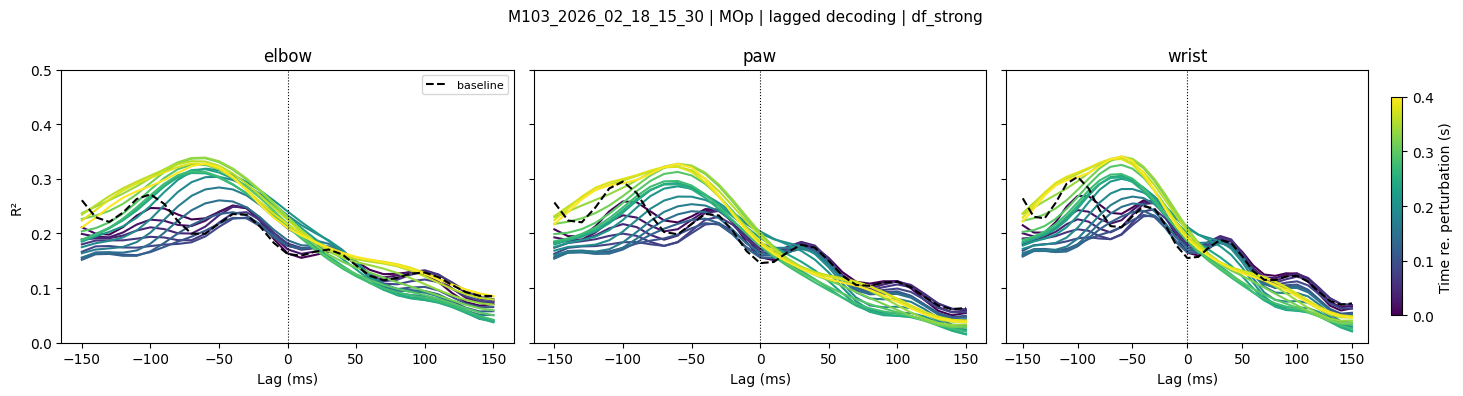

Baseline  : (-1.0, -0.3) s  (25 time bins)
Spaghetti : (0, 0.4) s  (20 time bins)


In [231]:
_all_t  = np.array(sorted(results[KEYPOINTS_LAG[0]].keys()))
_t_rel  = _all_t #- WINDOW_S

baseline_keys  = _all_t[(_t_rel >= BASELINE_S[0])  & (_t_rel < BASELINE_S[1])]
spaghetti_keys = _all_t[(_t_rel >= SPAGHETTI_S[0]) & (_t_rel < SPAGHETTI_S[1])]
lags_ms = LAGS_S * 1000
cmap    = mpl.cm.get_cmap('viridis', len(spaghetti_keys))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, keypoint in zip(axes, KEYPOINTS_LAG):
    res = results[keypoint]
    baseline = np.stack([res[k].mean(axis=1) for k in baseline_keys]).mean(axis=0)

    for i, k in enumerate(spaghetti_keys):
        vizutils.shaded_errorbar(ax, lags_ms, res[k], errorStat=scipy.stats.sem,
                                 alpha_err=0, color=cmap(i))

    ax.plot(lags_ms, baseline, color='k', lw=1.5, ls='--', zorder=10, label='baseline')
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel('Lag (ms)')
    ax.set_title(keypoint.replace('left_', ''))

axes[0].set_ylabel('R²')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 0.5)

sm = mpl.cm.ScalarMappable(cmap='viridis', norm=mpl.colors.Normalize(SPAGHETTI_S[0], SPAGHETTI_S[1]))
sm.set_array([])
plt.colorbar(sm, ax=axes[-1], label='Time re. perturbation (s)', shrink=0.8)

fig.suptitle(f'{perturb_td_shuff.session.values[0]} | {area} | lagged decoding | df_strong', fontsize=11)
fig.tight_layout()
plt.show()
    
print(f"Baseline  : {BASELINE_S} s  ({len(baseline_keys)} time bins)")
print(f"Spaghetti : {SPAGHETTI_S} s  ({len(spaghetti_keys)} time bins)")


In [255]:
baseline_keys

array([-0.8 , -0.78, -0.76, -0.74, -0.72, -0.7 , -0.68, -0.66, -0.64,
       -0.62, -0.6 , -0.58, -0.56, -0.54, -0.52, -0.5 , -0.48, -0.46,
       -0.44, -0.42, -0.4 , -0.38, -0.36, -0.34, -0.32])

KeyError: -0.8

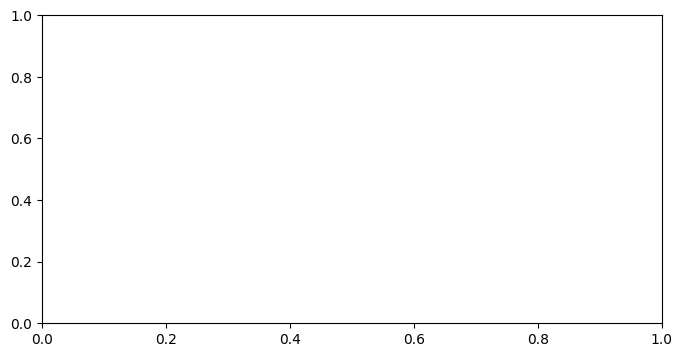

In [254]:
from scipy.signal import correlate

def _compute_drift(curve, baseline, lags):
    c  = curve    / (curve.max()    + 1e-12)
    b  = baseline / (baseline.max() + 1e-12)
    xc = correlate(c, b, mode='full')
    step = lags[1] - lags[0]
    pk   = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * step - (len(lags) - 1) * step
    return (pk - (len(lags) - 1)) * step

fig, ax = plt.subplots(figsize=(8, 4))

for keypoint in KEYPOINTS_LAG:
    # res = results[keypoint]
    res=results_anchored[keypoint]
    baseline = np.stack([res[k].mean(axis=1) for k in baseline_keys]).mean(axis=0)
    drift = np.array([_compute_drift(res[k].mean(axis=1), baseline, lags_ms) for k in _all_t])
    ax.plot(_t_rel, drift, label=keypoint.replace('left_', ''))
    print(f"{keypoint:12s} | peak drift = {drift.max():+.1f} ms at t = {_t_rel[drift.argmax()]:.2f} s")

ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(0, color='k', lw=0.8, ls=':')
ax.axvspan(BASELINE_S[0],  BASELINE_S[1],  alpha=0.08, color='grey', label='baseline')
ax.axvspan(SPAGHETTI_S[0], SPAGHETTI_S[1], alpha=0.08, color='blue',  label='spaghetti window')
ax.set_xlabel('Time re. perturbation (s)')
ax.set_ylabel('Lag drift (ms)')
ax.set_title(f'{area} | lag drift vs baseline | df_strong')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


In [129]:
curve[:t0_idx] - baseline[:t0_idx]

array([ 0.03944236,  0.07328549,  0.09573302,  0.09801788,  0.07855829,
        0.04423964,  0.00881494, -0.01400442, -0.02064126, -0.01913679,
       -0.01887773, -0.01965901, -0.01286771,  0.00770594,  0.03951176])

left_elbow   | past peak = 0.998 at t = 0.32 s  |  future peak = 0.237 at t = 0.36 s
left_paw     | past peak = 0.772 at t = 0.34 s  |  future peak = 0.117 at t = -0.62 s
left_wrist   | past peak = 0.788 at t = 0.34 s  |  future peak = 0.112 at t = 0.18 s


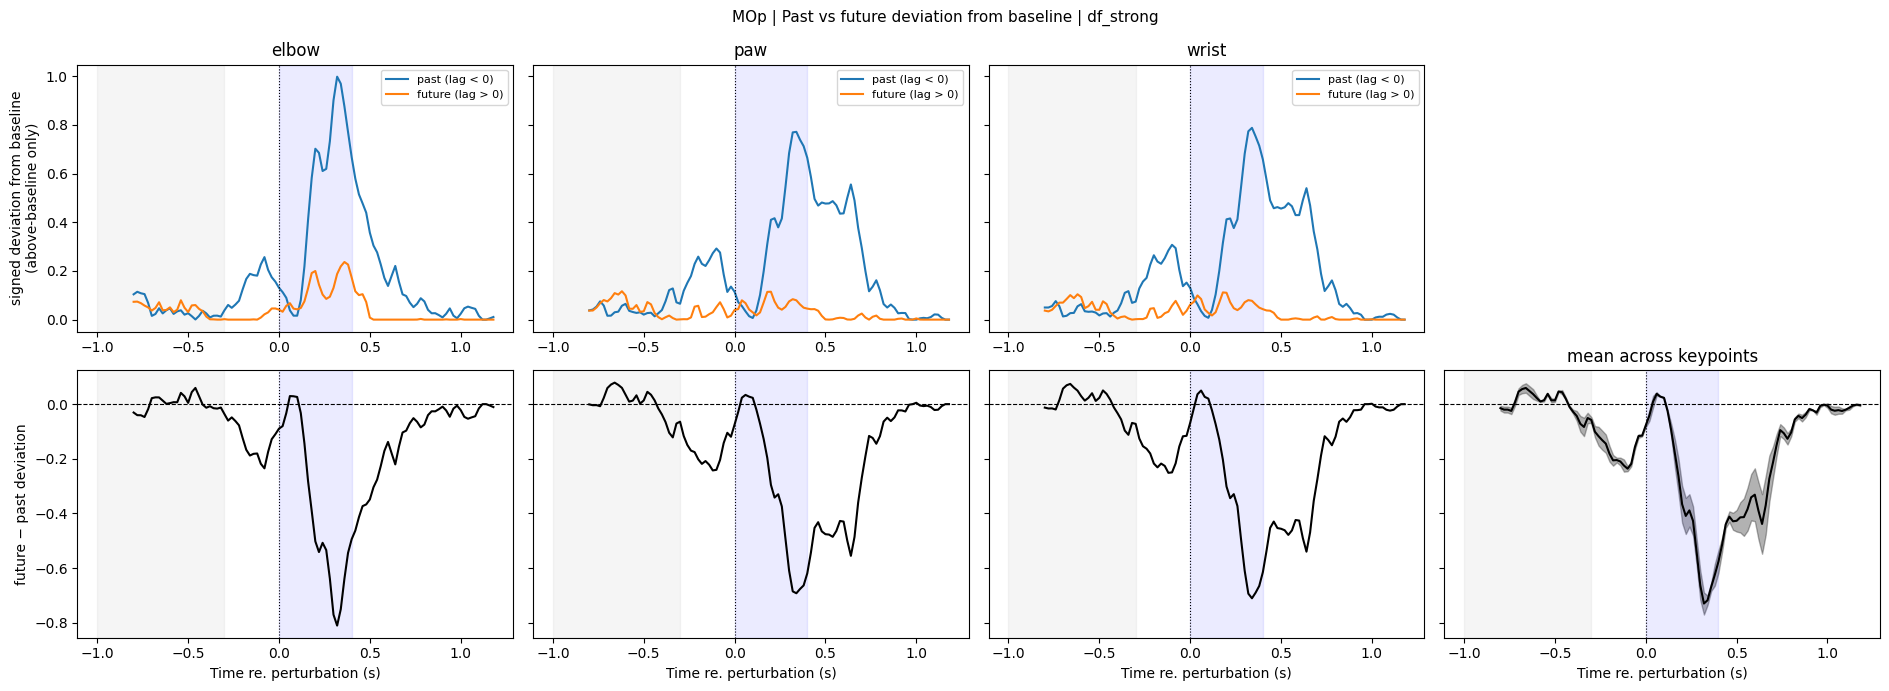

In [233]:
t0_idx = np.argmin(np.abs(lags_ms))  # index of lag = 0

fig, axes = plt.subplots(2, 4, figsize=(19, 7), sharey='row')
axes[0, 3].set_visible(False)  # top-right panel unused

all_diffs = []

for j, keypoint in enumerate(KEYPOINTS_LAG):
    res = results[keypoint]
    baseline = np.stack([res[k].mean(axis=1) for k in baseline_keys]).mean(axis=0)

    past_dev, future_dev = [], []
    for k in _all_t:
        curve = res[k].mean(axis=1)
        past_dev.append(  np.sum(np.maximum(curve[:t0_idx] - baseline[:t0_idx], 0)))
        future_dev.append(np.sum(np.maximum(curve[t0_idx:] - baseline[t0_idx:], 0)))

    past_dev   = np.array(past_dev)
    future_dev = np.array(future_dev)
    diff       = future_dev - past_dev
    all_diffs.append(diff)

    ax_top = axes[0, j]
    ax_top.plot(_t_rel, past_dev,   label='past (lag < 0)')
    ax_top.plot(_t_rel, future_dev, label='future (lag > 0)')
    ax_top.axvline(0, color='k', lw=0.8, ls=':')
    ax_top.axvspan(BASELINE_S[0],  BASELINE_S[1],  alpha=0.08, color='grey')
    ax_top.axvspan(SPAGHETTI_S[0], SPAGHETTI_S[1], alpha=0.08, color='blue')
    ax_top.set_title(keypoint.replace('left_', ''))
    ax_top.legend(fontsize=8)

    ax_bot = axes[1, j]
    ax_bot.plot(_t_rel, diff, color='k')
    ax_bot.axhline(0, color='k', lw=0.8, ls='--')
    ax_bot.axvline(0, color='k', lw=0.8, ls=':')
    ax_bot.axvspan(BASELINE_S[0],  BASELINE_S[1],  alpha=0.08, color='grey')
    ax_bot.axvspan(SPAGHETTI_S[0], SPAGHETTI_S[1], alpha=0.08, color='blue')
    ax_bot.set_xlabel('Time re. perturbation (s)')

    print(f"{keypoint:12s} | past peak = {past_dev.max():.3f} at t = {_t_rel[past_dev.argmax()]:.2f} s"
          f"  |  future peak = {future_dev.max():.3f} at t = {_t_rel[future_dev.argmax()]:.2f} s")
# ax_bot.set_ylim(-0.5, 0.5)
# mean ± SEM across keypoints
all_diffs  = np.stack(all_diffs)   # (3, n_times)
mean_diff  = all_diffs.mean(axis=0)
sem_diff   = scipy.stats.sem(all_diffs, axis=0)

ax_mean = axes[1, 3]
ax_mean.fill_between(_t_rel, mean_diff - sem_diff, mean_diff + sem_diff, alpha=0.3, color='k')
ax_mean.plot(_t_rel, mean_diff, color='k')
ax_mean.axhline(0, color='k', lw=0.8, ls='--')
ax_mean.axvline(0, color='k', lw=0.8, ls=':')
ax_mean.axvspan(BASELINE_S[0],  BASELINE_S[1],  alpha=0.08, color='grey')
ax_mean.axvspan(SPAGHETTI_S[0], SPAGHETTI_S[1], alpha=0.08, color='blue')
ax_mean.set_title('mean across keypoints')
ax_mean.set_xlabel('Time re. perturbation (s)')

axes[0, 0].set_ylabel('signed deviation from baseline\n(above-baseline only)')
axes[1, 0].set_ylabel('future − past deviation')
fig.suptitle(f'{area} | Past vs future deviation from baseline | df_strong', fontsize=11)
fig.tight_layout()
plt.show()

KeyError: -0.8

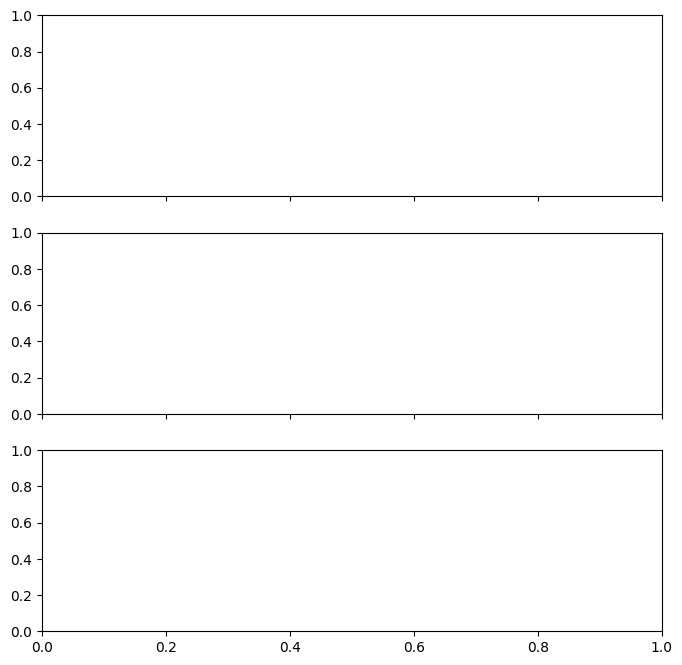

In [257]:
from scipy.optimize import curve_fit

def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2))

bounds = ([0, lags_ms[0], 5], [1, lags_ms[-1], 300])

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)
peaks_ = []
for keypoint in KEYPOINTS_LAG:
    # res = results[keypoint]
    res=results_anchored[keypoint]
    peaks, amplitudes, sigmas = [], [], []

    for k in _all_t:
        curve = res[k].mean(axis=1)
        try:
            p0 = [np.clip(curve.max(), 0, 1), lags_ms[curve.argmax()], 30.0]
            popt, _ = curve_fit(gaussian, lags_ms, curve, p0=p0, bounds=bounds, maxfev=5000)
            amplitudes.append(popt[0])
            peaks.append(popt[1])
            sigmas.append(abs(popt[2]))
        except (RuntimeError, ValueError):
            amplitudes.append(np.nan)
            peaks.append(np.nan)
            sigmas.append(np.nan)

    label = keypoint.replace('left_', '')
    axes[0].plot(_t_rel, peaks,      label=label)
    axes[1].plot(_t_rel, amplitudes, label=label)
    axes[2].plot(_t_rel, sigmas,     label=label)
    peaks_.append(np.array(peaks))
    print(f"{keypoint:12s} | peak range {np.nanmin(peaks):+.1f} → {np.nanmax(peaks):+.1f} ms")

vizutils.shaded_errorbar(axes[0], _t_rel, np.array(peaks_).T, color='k')

for ax in axes:
    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axvspan(BASELINE_S[0],  BASELINE_S[1],  alpha=0.08, color='grey')
    ax.axvspan(SPAGHETTI_S[0], SPAGHETTI_S[1], alpha=0.08, color='blue')
    ax.legend(fontsize=8)

axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_ylabel('Gaussian peak (ms)')
axes[1].set_ylabel('Amplitude (R²)')
axes[2].set_ylabel('Sigma (ms)')
axes[2].set_xlabel('Time re. perturbation (s)')

fig.suptitle(f'{area} | Gaussian fit to lag curves | df_strong')
fig.tight_layout()
plt.show()
